In [1]:
import pandas as pd

df = pd.read_csv("dairy_sales_dataset_v2.csv")

In [2]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df = df.drop("Date", axis=1)

In [3]:
df = pd.get_dummies(df, columns=["Product", "Store_Type", "Store_Size"], drop_first=True)

In [4]:
df.head()
df.columns

Index(['Price_per_Unit', 'Units_Sold', 'Holiday', 'Temperature', 'Discount',
       'Marketing_Spend', 'Competitor_Price', 'Day_of_Week', 'Is_Weekend',
       'Stock_Available', 'Sales', 'Month', 'Day', 'Product_Curd',
       'Product_Milk', 'Product_Paneer', 'Store_Type_Urban',
       'Store_Size_Medium', 'Store_Size_Small'],
      dtype='object')

In [5]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
X_train.head()

,Price_per_Unit,Units_Sold,Holiday,Temperature,Discount,Marketing_Spend,Competitor_Price,Day_of_Week,Is_Weekend,Stock_Available,Month,Day,Product_Curd,Product_Milk,Product_Paneer,Store_Type_Urban,Store_Size_Medium,Store_Size_Small
55,44.93,11,1,12.1,0.16,8761.27,53.99,7,0,67,2,25,False,False,False,False,True,False
88,56.36,172,0,10.3,0.25,4278.43,91.94,5,0,296,3,30,False,False,False,True,True,False
26,97.13,157,1,28.5,0.28,4223.46,99.60,1,1,133,1,27,False,False,True,False,False,False
42,96.08,20,1,29.3,0.19,2916.68,108.72,1,1,428,2,12,False,False,True,False,False,False
69,73.93,129,1,32.5,0.29,2152.41,88.10,6,1,313,3,11,False,False,True,True,False,True


In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1296.540164999999
R2 Score: 0.9035981061787731


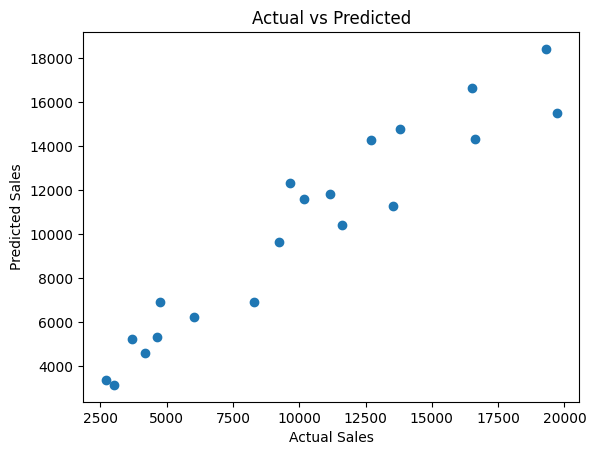

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

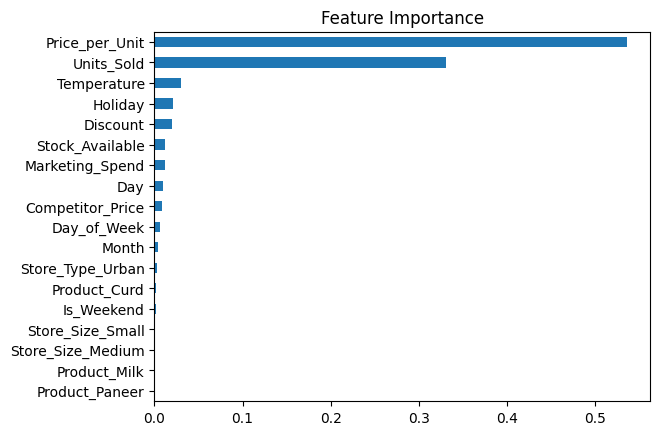

In [12]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [13]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']